# QSVT Exact Linear Solver Toy Cases

This tutorial combines the previous 2x2 and 4x4 exact linear-solver examples.
Both systems use involutory Hermitian matrices with eigenvalues in
`{-1, 1}`. For these matrices,

$$A^2 = I \quad\Rightarrow\quad A^{-1} = A,$$

so the bounded polynomial

$$P(x)=x$$

implements the inverse exactly on the spectrum. These are toy cases for
understanding the QSVT transform; the approximate inverse tutorial that follows
covers the nontrivial case where a polynomial only approximates inverse
behavior.

## Imports

The examples use the package matrix helper, polynomial diagnostics, and the
finite QSVT top-left block extraction helper.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.matrices import pauli_x
from qsvt.polynomials import eval_polynomial, polynomial_parity
from qsvt.qsvt import qsvt_top_left_block

## Polynomial

The same odd, bounded polynomial works for both exact toy systems.

Polynomial coefficients: [0. 1.]
Polynomial parity: odd


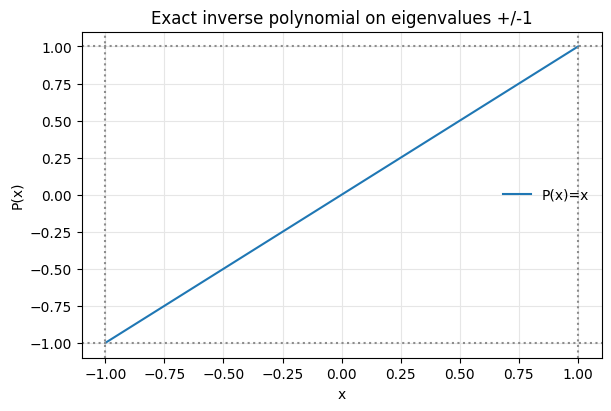

In [2]:
poly = np.array([0.0, 1.0])
xs = np.linspace(-1.0, 1.0, 200)

print("Polynomial coefficients:", poly)
print("Polynomial parity:", polynomial_parity(poly))

fig, ax = plt.subplots(figsize=(6.0, 4.0), constrained_layout=True)
ax.plot(xs, eval_polynomial(poly, xs), label="P(x)=x")
ax.axhline(-1.0, color="0.55", linestyle=":")
ax.axhline(1.0, color="0.55", linestyle=":")
ax.axvline(-1.0, color="0.55", linestyle=":")
ax.axvline(1.0, color="0.55", linestyle=":")
ax.set_xlabel("x")
ax.set_ylabel("P(x)")
ax.set_title("Exact inverse polynomial on eigenvalues +/-1")
ax.grid(True, color="0.9")
ax.legend(frameon=False)
plt.show()

## Shared Solver Check

The helper below compares the classical solution with the QSVT-transformed
logical block. The comparison is on normalized solution states because QSVT
linear-system workflows usually return states rather than full classical vector
readout.

In [3]:
def run_exact_inverse_case(name, matrix, rhs, encoding_wires):
    classical_solution = np.linalg.solve(matrix, rhs)
    classical_state = classical_solution / np.linalg.norm(classical_solution)

    qsvt_block = qsvt_top_left_block(
        matrix,
        poly,
        encoding_wires=encoding_wires,
    )
    qsvt_solution = qsvt_block @ rhs
    qsvt_state = qsvt_solution / np.linalg.norm(qsvt_solution)

    block_error = np.linalg.norm(qsvt_block.real - matrix)
    state_error = np.linalg.norm(qsvt_state.real - classical_state)

    print(name)
    print("-" * len(name))
    print("eigenvalues:", np.linalg.eigvalsh(matrix))
    print("rhs:", rhs)
    print("classical solution:", classical_solution)
    print("QSVT block real-part error:", f"{block_error:.3e}")
    print("normalized solution-state error:", f"{state_error:.3e}")
    print()

    return {
        "name": name,
        "matrix": matrix,
        "rhs": rhs,
        "classical_state": classical_state,
        "qsvt_state": qsvt_state,
        "block_error": block_error,
        "state_error": state_error,
    }

## 2x2 Case

The 2x2 case uses the Pauli-X matrix. It is the smallest nontrivial exact
linear-solver example in this sequence.

In [4]:
case_2x2 = run_exact_inverse_case(
    "2x2 Pauli-X system",
    pauli_x(),
    np.array([1.0, 2.0], dtype=float),
    encoding_wires=[0, 1],
)

2x2 Pauli-X system
------------------
eigenvalues: [-1.  1.]
rhs: [1. 2.]
classical solution: [2. 1.]
QSVT block real-part error: 1.414e-12
normalized solution-state error: 9.998e-13



## 4x4 Case

The 4x4 case uses a diagonal involutory matrix. It demonstrates that the same
polynomial logic extends beyond one data qubit without needing a separate
tutorial notebook.

In [5]:
case_4x4 = run_exact_inverse_case(
    "4x4 diagonal involutory system",
    np.diag([1.0, -1.0, 1.0, -1.0]),
    np.array([1.0, 2.0, 3.0, 4.0], dtype=float),
    encoding_wires=[0, 1, 2],
)

4x4 diagonal involutory system
------------------------------
eigenvalues: [-1. -1.  1.  1.]
rhs: [1. 2. 3. 4.]
classical solution: [ 1. -2.  3. -4.]
QSVT block real-part error: 2.000e-12
normalized solution-state error: 1.000e-12



## Solution-State Comparison

Both examples agree with the classical normalized solution state up to small
finite backend numerical error.

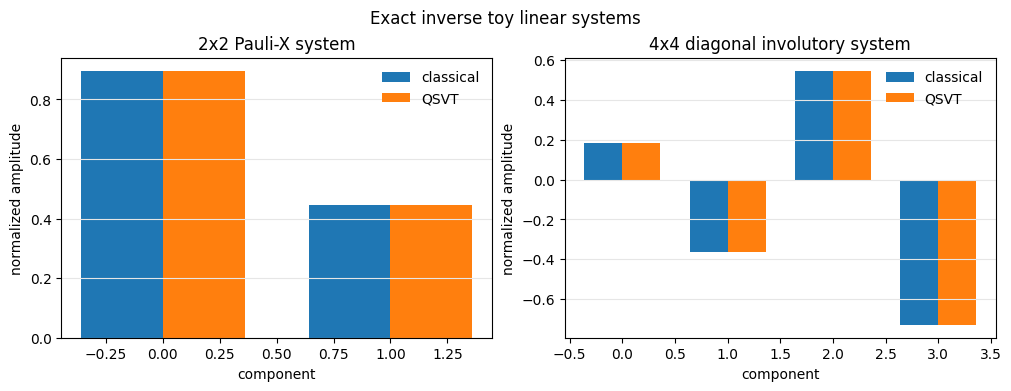

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8), constrained_layout=True)
for ax, case in zip(axes, [case_2x2, case_4x4]):
    x = np.arange(case["classical_state"].size)
    width = 0.36
    ax.bar(x - width / 2, case["classical_state"].real, width, label="classical")
    ax.bar(x + width / 2, case["qsvt_state"].real, width, label="QSVT")
    ax.set_title(case["name"])
    ax.set_xlabel("component")
    ax.set_ylabel("normalized amplitude")
    ax.grid(True, axis="y", color="0.9")
    ax.legend(frameon=False)
fig.suptitle("Exact inverse toy linear systems")
plt.show()

## Approximate inverse-like polynomials

The exact toy cases above use involutory spectra, so the bounded odd polynomial `P(x) = x` already acts like the inverse on the eigenvalue signs. For non-involutory spectra, the same idea is to choose a bounded odd polynomial whose values have the right relative signs and magnitudes on the finite spectrum being studied.

For example, on eigenvalues `[-0.5, 0.5]`, the Chebyshev polynomial `T_3(x) = 4x^3 - 3x` gives `T_3(-0.5) = 1` and `T_3(0.5) = -1`. That does not reproduce the unnormalized inverse eigenvalues `[-2, 2]`, but it matches the inverse solution direction up to a global scale and sign. This is the useful lesson from the former approximate-solver notebook: QSVT linear-system demos should usually compare normalized solution states and report approximation error, boundedness, and success probability rather than implying a free exact inverse.

For practical degree sweeps, resource proxies, and classical baselines, use `16_QSVT_Linear_System_Comparisons.ipynb`. For an explicit HHL comparison, use `17_HHL_Linear_System_Solver.ipynb`.


## Next Step

These exact cases are useful for validating conventions, block extraction, and state normalization. Move next to `16_QSVT_Linear_System_Comparisons.ipynb` for practical approximate linear-system workflows, and to `17_HHL_Linear_System_Solver.ipynb` when you want a simulator-scale HHL comparison.
